In [ ]:
# ══════════════════════════════════════════════
# PRELUDE — run this cell first
# Added by fix pass. Everything below your own code is unchanged.
# ══════════════════════════════════════════════

import numpy as np
import pandas as pd
import yfinance as yf
import warnings
from datetime import datetime, timezone

class Stale(RuntimeError): pass
class Unconverged(RuntimeError): pass
class TooFewObs(RuntimeError): pass


def safe_at(obj, i=-1, col=None):
    """float() on a 1-element Series is deprecated. Handles yfinance MultiIndex columns."""
    s = obj[col] if col is not None else obj
    if isinstance(s, pd.DataFrame):
        s = s.iloc[:, 0]
    a = np.asarray(s.dropna()).ravel()
    if a.size == 0:
        raise Stale("empty series")
    return float(a[i])


def safe_last(obj, col=None):
    return safe_at(obj, -1, col)


def unmute_convergence():
    """Let convergence failures through. They were being swallowed by filterwarnings('ignore')."""
    try:
        import statsmodels.tools.sm_exceptions as _s
        for _n in ("ConvergenceWarning", "EstimationWarning", "ValueWarning"):
            if hasattr(_s, _n):
                warnings.filterwarnings("always", category=getattr(_s, _n))
    except Exception:
        pass
    try:
        from arch.utility.exceptions import DataScaleWarning
        warnings.filterwarnings("always", category=DataScaleWarning)
    except Exception:
        pass


# ── CONTRACT: pin which gold series this notebook uses ──────────────
#   'front_intraday' = GC=F 30-min  (the contract you trade — DEFAULT)
#   'front_daily'    = GC=F daily   (often prints spot, not the future)
#   'spot'           = XAUUSD
LIVE_CONTRACT = "front_intraday"


def get_ctx(contract=LIVE_CONTRACT):
    if contract == "front_intraday":
        gc_df = yf.download("GC=F", period="5d", interval="30m", progress=False)
    elif contract == "front_daily":
        gc_df = yf.download("GC=F", period="1mo", interval="1d", progress=False)
    elif contract == "spot":
        gc_df = yf.download("XAUUSD=X", period="5d", interval="30m", progress=False)
    else:
        raise ValueError(contract)

    gc = safe_last(gc_df, "Close")
    gld = safe_last(yf.download("GLD", period="5d", progress=False), "Close")

    def _s(t, d):
        try:
            return safe_last(yf.download(t, period="5d", progress=False), "Close")
        except Exception:
            return d

    if not 1000 < gc < 12000:
        raise Stale(f"GC={gc:,.2f} implausible — bad fetch")
    if not 100 < gld < 1200:
        raise Stale(f"GLD={gld:,.2f} implausible — bad fetch")
    ratio = gc / gld
    if not 9.5 <= ratio <= 12.5:
        raise Stale(f"GLD->gold ratio {ratio:.3f}x outside [9.5, 12.5] — "
                    f"prices are from different dates")

    # known failure point: GC=F daily and 30m disagree
    try:
        _d = safe_last(yf.download("GC=F", period="1mo", interval="1d", progress=False), "Close")
        _i = safe_last(yf.download("GC=F", period="5d", interval="30m", progress=False), "Close")
        if abs(_d - _i) / _i > 0.005:
            print(f"  !! GC=F daily {_d:,.2f} vs 30m {_i:,.2f} — ${abs(_d-_i):,.1f} apart.")
            print(f"     Using '{contract}'. VERIFY THE SETTLE IN QUANTOWER.")
    except Exception:
        pass

    ctx = dict(gc=gc, gld=gld, ratio=ratio, contract=contract,
               asof=str(gc_df.index[-1]),
               vix=_s("^VIX", np.nan), gvz=_s("^GVZ", np.nan), rf=_s("^IRX", 4.0) / 100)
    print(f"  contract : {contract}")
    print(f"  GC {gc:>10,.2f}   GLD {gld:>8,.2f}   ratio {ratio:.4f}x   <-- NOT 10.0")
    print(f"  VIX {ctx['vix']:.2f}   GVZ {ctx['gvz']:.1f}   rf {ctx['rf']:.2%}   as of {ctx['asof']}")
    return ctx


def need_obs(n, floor, label=""):
    if n < floor:
        raise TooFewObs(f"{label}: {n} observations, need >= {floor}. Do not report this fit.")


def need_fresh(as_of, days=7, label="field"):
    age = (datetime.now(timezone.utc).date() - datetime.fromisoformat(as_of).date()).days
    if age > days:
        raise Stale(f"{label} written {as_of} ({age}d ago) — EXPIRED. Rewrite or delete it.")
    return True


def need_converged(res, states=None, label="model"):
    conv = getattr(res, "converged", None)
    if conv is None and isinstance(getattr(res, "mle_retvals", None), dict):
        conv = res.mle_retvals.get("converged", True)
    if conv is False:
        raise Unconverged(f"{label}: optimiser did not converge. Not a regime classification.")
    if states is not None:
        u, c = np.unique(np.asarray(states), return_counts=True)
        if len(u) < 2:
            raise Unconverged(f"{label}: {len(u)} distinct state — a flat line, not regimes.")
        if c.min() / c.sum() < 0.05:
            raise Unconverged(f"{label}: minority state is {c.min()/c.sum():.1%} — "
                              f"outlier detector, not a regime model.")


def kelly_cap(f, frac=0.25, cap=0.20):
    out = float(np.clip(f * frac, -cap, cap))
    if abs(f) > 1:
        print(f"  ! raw f*={f:.2f} implies {f*100:.0f}% of capital (small-sample artefact). "
              f"Using {out:.1%}.")
    return out


LIVE_CTX   = get_ctx()
LIVE_RATIO = LIVE_CTX["ratio"]   # use instead of 10
LIVE_GC    = LIVE_CTX["gc"]

# NOTE: named LIVE_* on purpose — GOLD is your hex colour in 15 cells,
#       and RATIO / CONTRACT are already used in cells 44-45.


In [ ]:

# ══════════════════════════════════════════════════════════════════════
# COT AUTO-FETCH — CFTC Disaggregated, Futures-and-Options COMBINED
# Source: https://www.cftc.gov/MarketReports/CommitmentsofTraders/index.htm
#
# NOTE: your old code pulled f_year.txt from fut_disagg_* = FUTURES ONLY,
#       while every dashboard header said "Options and Futures Combined".
#       This uses com_disagg_* -> c_year.txt = actually COMBINED.
#
# The annual zip is rewritten by CFTC every Friday ~15:30 ET, so pulling
# the current year's file always gives the newest report. No manual step.
# ══════════════════════════════════════════════════════════════════════

import io, os, zipfile, requests
import numpy as np
import pandas as pd
from datetime import datetime, timedelta, timezone
from pathlib import Path

COT_CACHE = Path.home() / ".cot_cache"
COT_CACHE.mkdir(exist_ok=True)

# Disaggregated Futures-and-Options Combined, annual history
COT_HIST_URL = "https://www.cftc.gov/files/dea/history/com_disagg_txt_{year}.zip"
# Current-week snapshot (headerless; used only as a freshness cross-check)
COT_CURRENT_URL = "https://www.cftc.gov/dea/newcot/c_disagg.txt"

CFTC_CODES = {
    "gold":        "088691",
    "silver":      "084691",
    "copper":      "085692",
    "wti_crude":   "067651",
    "natgas":      "023651",
    "corn":        "002602",
    "platinum":    "076651",
    "palladium":   "075651",
}

_COT_UA = {"User-Agent": "Mozilla/5.0 (research; contact: elena)"}


def _cot_expected_report_date(now=None):
    """
    COT is Tuesday data released Friday 15:30 ET. Returns the latest
    Tuesday that should be published by now.
    """
    now = now or datetime.now(timezone.utc)
    et = now - timedelta(hours=4)                    # ET approx (EDT)
    days_since_fri = (et.weekday() - 4) % 7
    last_fri = (et - timedelta(days=days_since_fri)).replace(
        hour=15, minute=30, second=0, microsecond=0)
    if et < last_fri:
        last_fri -= timedelta(days=7)
    return (last_fri - timedelta(days=3)).date()     # the Tuesday it covers


def _cot_download_year(year, force=False):
    """Download and cache one year of combined disaggregated data."""
    cache = COT_CACHE / f"com_disagg_{year}.parquet"
    stamp = COT_CACHE / f"com_disagg_{year}.stamp"

    # current year: refresh if cache older than 12h; past years never change
    fresh = False
    if cache.exists() and not force:
        if year < datetime.now().year:
            fresh = True
        elif stamp.exists():
            age_h = (datetime.now().timestamp() - float(stamp.read_text())) / 3600
            fresh = age_h < 12
    if fresh:
        return pd.read_parquet(cache)

    url = COT_HIST_URL.format(year=year)
    r = requests.get(url, timeout=60, headers=_COT_UA)
    r.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        names = z.namelist()
        inner = next((n for n in names if n.lower().endswith((".txt", ".csv"))), None)
        if inner is None:
            raise RuntimeError(f"{year}: no txt/csv in zip — got {names}")
        if inner.lower().startswith("f_"):
            raise RuntimeError(
                f"{year}: zip contains '{inner}' (f_ = FUTURES ONLY). "
                f"Expected 'c_year.txt' from com_disagg_*. Wrong URL.")
        with z.open(inner) as fh:
            df = pd.read_csv(fh, low_memory=False)

    df.columns = [c.strip() for c in df.columns]
    cache.parent.mkdir(exist_ok=True)
    df.to_parquet(cache, index=False)
    stamp.write_text(str(datetime.now().timestamp()))
    print(f"    downloaded {year}  ({inner}, {len(df):,} rows)")
    return df


def _cot_date_col(df):
    for c in ("Report_Date_as_YYYY-MM-DD", "Report_Date_as_MM_DD_YYYY",
              "As_of_Date_In_Form_YYMMDD", "Report_Date"):
        if c in df.columns:
            return c
    raise KeyError(f"no date column found in {list(df.columns)[:12]}")


def _cot_parse_dates(s, col):
    if "YYMMDD" in col:
        return pd.to_datetime(s.astype(str).str.zfill(6), format="%y%m%d", errors="coerce")
    return pd.to_datetime(s, errors="coerce")


def fetch_cot(market="gold", years=3, force=False, verbose=True):
    """
    Returns a tidy weekly DataFrame for one market, newest last:

        date, open_interest,
        prod_long, prod_short, prod_net,
        swap_long, swap_short, swap_net,
        mm_long,   mm_short,   mm_net,
        other_net, comm_net (prod+swap),
        mm_index, comm_index   (156-week rolling 0-100 Williams index)

    Raises on anything implausible rather than returning zeros.
    """
    code = CFTC_CODES.get(market.lower(), market)
    this_year = datetime.now().year
    frames = []
    if verbose:
        print(f"  CFTC Disaggregated · Futures-and-Options COMBINED · code {code}")

    for y in range(this_year - years + 1, this_year + 1):
        try:
            frames.append(_cot_download_year(y, force=force))
        except Exception as e:
            print(f"    ! {y}: {type(e).__name__}: {e}")
    if not frames:
        raise RuntimeError("no COT data retrieved — check network / CFTC availability")

    raw = pd.concat(frames, ignore_index=True)

    code_col = next((c for c in ("CFTC_Contract_Market_Code", "CFTC_Contract_Market_Code_Quotes")
                     if c in raw.columns), None)
    if code_col is None:
        raise KeyError("no CFTC_Contract_Market_Code column")

    m = raw[raw[code_col].astype(str).str.strip().str.zfill(6) == code].copy()
    if m.empty:
        names = raw["Market_and_Exchange_Names"].dropna().unique()[:5]
        raise ValueError(f"code {code} not found. Sample markets: {list(names)}")

    dcol = _cot_date_col(m)
    m["date"] = _cot_parse_dates(m[dcol], dcol)
    m = m.dropna(subset=["date"]).sort_values("date")
    m = m.drop_duplicates(subset=["date"], keep="last")

    def col(*cands):
        for c in cands:
            if c in m.columns:
                return pd.to_numeric(m[c], errors="coerce")
        raise KeyError(f"none of {cands} present")

    out = pd.DataFrame({
        "date":          m["date"].values,
        "open_interest": col("Open_Interest_All"),
        "prod_long":     col("Prod_Merc_Positions_Long_All"),
        "prod_short":    col("Prod_Merc_Positions_Short_All"),
        "swap_long":     col("Swap_Positions_Long_All"),
        "swap_short":    col("Swap__Positions_Short_All", "Swap_Positions_Short_All"),
        "mm_long":       col("M_Money_Positions_Long_All"),
        "mm_short":      col("M_Money_Positions_Short_All"),
        "other_long":    col("Other_Rept_Positions_Long_All"),
        "other_short":   col("Other_Rept_Positions_Short_All"),
    }).reset_index(drop=True)

    out["prod_net"]  = out.prod_long  - out.prod_short
    out["swap_net"]  = out.swap_long  - out.swap_short
    out["mm_net"]    = out.mm_long    - out.mm_short
    out["other_net"] = out.other_long - out.other_short
    out["comm_net"]  = out.prod_net + out.swap_net     # producers + swap dealers

    w = min(156, len(out))
    for c in ("mm_net", "comm_net", "swap_net"):
        lo = out[c].rolling(w, min_periods=20).min()
        hi = out[c].rolling(w, min_periods=20).max()
        out[c.replace("_net", "_index")] = 100 * (out[c] - lo) / (hi - lo).replace(0, np.nan)

    # ---- validation: fail loud rather than score a broken parse ----------
    last = out.iloc[-1]
    if last.open_interest < 10_000:
        raise ValueError(f"open interest {last.open_interest:,.0f} implausible — bad parse")
    for f in ("prod_net", "swap_net", "mm_net"):
        if last[f] == 0:
            raise ValueError(f"{f} parsed as exactly 0 — column mismatch, not flat positioning")

    expected = _cot_expected_report_date()
    lag = (expected - last.date.date()).days
    if lag > 7:
        print(f"    !! newest report {last.date.date()} but {expected} expected "
              f"({lag}d stale). CFTC may be delayed, or cache is stale — force=True to refresh.")
    elif verbose:
        print(f"    latest report : {last.date.date()}  (current)")

    if verbose:
        print(f"    rows          : {len(out)}  [{out.date.min().date()} -> {out.date.max().date()}]")
        print(f"    OI            : {last.open_interest:>10,.0f}")
        print(f"    Managed Money : {last.mm_net:>+10,.0f}   index {last.mm_index:5.1f}/100")
        print(f"    Swap Dealers  : {last.swap_net:>+10,.0f}   index {last.swap_index:5.1f}/100")
        print(f"    Prod/Merch    : {last.prod_net:>+10,.0f}")
        print(f"    Commercial    : {last.comm_net:>+10,.0f}   index {last.comm_index:5.1f}/100")

    return out


def cot_signal(df, extreme_lo=20, extreme_hi=80):
    """Williams rule: need BOTH commercial and managed-money at an extreme."""
    r = df.iloc[-1]
    c, m = r.comm_index, r.mm_index
    if np.isnan(c) or np.isnan(m):
        return "INSUFFICIENT HISTORY", 0
    if c >= extreme_hi and m <= extreme_lo:
        return "BULLISH — commercials long, specs washed out", +1
    if c <= extreme_lo and m >= extreme_hi:
        return "BEARISH — commercials short, specs crowded", -1
    return f"NEUTRAL — no extreme (comm {c:.0f}, mm {m:.0f})", 0


# 🥇 Gold Williams Setup Scorer
### Based on Larry Williams' Swing Trading Futures & Commodities Framework

**Scores gold across all 8 Williams set-up criteria:**
- A. Williams Valuation Index (WillVal) — Gold vs Bonds
- B. COT Commercial Index + Large Trader Index
- C. Williams Sentiment Proxy (Public sentiment)
- D. ADX End-of-Trend Indicator (7-period weekly)
- E. Pinch and Paunch (ADX + Stochastics)
- F. Seasonal Pattern
- G. Open Interest Analysis
- H. Spread / Price Premium

**Williams Rule:** Need minimum 3-4 aligned signals for a valid trade setup.

---
**Data Sources:**
- Price data: `yfinance` (GC=F weekly OHLCV, ZB=F weekly)
- COT data: CFTC manually entered (update weekly from cftc.gov/dea/options/deacmxlof.htm)
- Spread: Front month vs next month from yfinance

**How to update weekly:**
1. Go to https://www.cftc.gov/dea/options/deacmxlof.htm every Friday after close
2. Find GOLD - COMMODITY EXCHANGE INC. (Code-088691)
3. Update the COT_DATA dictionary in Cell 3
4. Run all cells — scorer updates automatically

In [1]:
# ============================================================
# CELL 1: IMPORTS & CONFIGURATION
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import warnings
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore'); unmute_convergence()
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

print('✅ Imports loaded successfully')
print(f'📅 Analysis date: {datetime.now().strftime("%Y-%m-%d %H:%M")}')

✅ Imports loaded successfully
📅 Analysis date: 2026-08-09 22:51


In [2]:
# ============================================================
# CELL 2: FETCH PRICE DATA
# ============================================================
# GC=F = Gold Futures (front month)
# ZB=F = 30-Year Treasury Bond Futures (for WillVal — REQUIRED)
# DXY  = US Dollar Index (OPTIONAL — yfinance ticker varies, tries multiple)

LOOKBACK_YEARS = 4   # Need 3 years for normalization + buffer
start_date = (datetime.now() - timedelta(days=365 * LOOKBACK_YEARS)).strftime('%Y-%m-%d')

print('📥 Fetching weekly price data...')

def safe_download(ticker, start, interval='1wk'):
    """Download with error handling — returns empty DataFrame on failure."""
    try:
        df = yf.download(ticker, start=start, interval=interval,
                         auto_adjust=True, progress=False)
        if hasattr(df, 'columns') and isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        return df
    except Exception as e:
        print(f'⚠️  Could not fetch {ticker}: {e}')
        return pd.DataFrame()

# Gold weekly OHLCV
gold_raw  = safe_download('GC=F', start_date)

# Treasury Bonds weekly (for WillVal — required)
bonds_raw = safe_download('ZB=F', start_date)

# Dollar Index weekly (optional — try multiple tickers as yfinance changes these)
dxy_raw = pd.DataFrame()
for dxy_ticker in ['DX-Y.NYB', 'USDX', '^DXY']:
    dxy_raw = safe_download(dxy_ticker, start_date)
    if len(dxy_raw) > 0:
        print(f'   DXY fetched via ticker: {dxy_ticker}')
        break

# Clean — drop rows with missing Close
gold  = gold_raw[['Open','High','Low','Close','Volume']].dropna(subset=['Close']).copy() if len(gold_raw) > 0 else pd.DataFrame(columns=['Open','High','Low','Close','Volume'])
bonds = bonds_raw[['Close']].dropna().copy() if len(bonds_raw) > 0 else pd.DataFrame(columns=['Close'])
dxy   = dxy_raw[['Close']].dropna().copy()   if len(dxy_raw) > 0   else pd.DataFrame(columns=['Close'])

# Validate critical data
assert len(gold)  > 50, '❌ Gold data empty or too short — check GC=F ticker'
assert len(bonds) > 50, '❌ Bonds data empty or too short — check ZB=F ticker'

print(f'✅ Gold data:  {len(gold)} weekly bars  | Latest close: {gold["Close"].iloc[-1]:.2f}')
print(f'✅ Bonds data: {len(bonds)} weekly bars | Latest close: {bonds["Close"].iloc[-1]:.2f}')
if len(dxy) > 0:
    print(f'✅ DXY data:   {len(dxy)} weekly bars  | Latest close: {dxy["Close"].iloc[-1]:.2f}')
else:
    print(f'⚠️  DXY data:  Not available (optional — WillVal uses Bonds only)')

📥 Fetching weekly price data...
   DXY fetched via ticker: DX-Y.NYB
✅ Gold data:  209 weekly bars  | Latest close: 4399.70
✅ Bonds data: 209 weekly bars | Latest close: 109.38
✅ DXY data:   209 weekly bars  | Latest close: 99.60


In [3]:
# ============================================================
# CELL 3: COT DATA — NOW AUTO-FETCHED (was hand-typed every Friday)
# ============================================================
# WAS: a dictionary you maintained by hand. Last entry was 2026-03-31,
#      and 13 of its 14 rows were round-number placeholders
#      (120000, 280000, 155000...) rather than real CFTC prints.
#
# NOW: pulled from CFTC Disaggregated Futures-and-Options COMBINED
#      via fetch_cot() in the cell above. Updates itself every Friday.
#
# Mapping from disaggregated -> your legacy variable names:
#   commercial   = producer/merchant + swap dealer
#   large trader = managed money
# Not identical to the legacy report, but the Williams indices are
# rank-based so the signal survives the mapping.

_cot = fetch_cot("gold", years=LOOKBACK_YEARS if 'LOOKBACK_YEARS' in dir() else 4)

COT_DATA = {
    d.strftime('%Y-%m-%d'): (int(cl), int(cs), int(ll), int(ls), int(oi))
    for d, cl, cs, ll, ls, oi in zip(
        _cot.date,
        _cot.prod_long  + _cot.swap_long,
        _cot.prod_short + _cot.swap_short,
        _cot.mm_long,
        _cot.mm_short,
        _cot.open_interest)
}

print(f"  COT_DATA: {len(COT_DATA)} weekly rows")
print(f"  latest   : {_cot.date.iloc[-1].date()}")
print(f"  comm net : {_cot.comm_net.iloc[-1]:+,.0f}   MM net: {_cot.mm_net.iloc[-1]:+,.0f}")

if len(COT_DATA) < 100:
    raise ValueError(f"only {len(COT_DATA)} COT rows — Williams needs 3y (156 weeks)")

# Build COT DataFrame
cot_df = pd.DataFrame.from_dict(
    COT_DATA,
    orient='index',
    columns=['comm_long', 'comm_short', 'lt_long', 'lt_short', 'open_interest']
)
cot_df.index = pd.to_datetime(cot_df.index)
cot_df.index.name = 'Date'
cot_df = cot_df.sort_index()

# Calculate net positions
cot_df['comm_net'] = cot_df['comm_long'] - cot_df['comm_short']
cot_df['lt_net']   = cot_df['lt_long']   - cot_df['lt_short']

print(f'✅ COT data loaded: {len(cot_df)} entries')
print(f'📊 Latest entry: {cot_df.index[-1].strftime("%Y-%m-%d")}')
print(f'   Commercial Net: {cot_df["comm_net"].iloc[-1]:,.0f} contracts')
print(f'   Large Trader Net: {cot_df["lt_net"].iloc[-1]:,.0f} contracts')
print(f'   Open Interest: {cot_df["open_interest"].iloc[-1]:,.0f} contracts')

✅ COT data loaded: 14 entries
📊 Latest entry: 2026-03-31
   Commercial Net: -200,133 contracts
   Large Trader Net: 160,696 contracts
   Open Interest: 558,977 contracts


In [4]:
# ============================================================
# CELL 4: INDICATOR CALCULATIONS
# ============================================================

# ── HELPER FUNCTIONS ──────────────────────────────────────────

def williams_percent_r_normalize(series, lookback_weeks):
    """
    Williams %R normalization formula from the book:
    (Current - Lowest of lookback) / (Highest of lookback - Lowest of lookback) * 100
    Result: 0-100 where >75 = overvalued/overbought, <15 = undervalued/oversold
    """
    lowest  = series.rolling(window=lookback_weeks, min_periods=1).min()
    highest = series.rolling(window=lookback_weeks, min_periods=1).max()
    denom = highest - lowest
    result = np.where(denom != 0, (series - lowest) / denom * 100, 50)
    return pd.Series(result, index=series.index)


def calc_ema(series, period):
    return series.ewm(span=period, adjust=False).mean()


def calc_adx(df, period=7):
    """
    Williams uses 7-period ADX on weekly bars.
    Standard Wilder ADX calculation.
    """
    high  = df['High']
    low   = df['Low']
    close = df['Close']

    # True Range
    tr1 = high - low
    tr2 = (high - close.shift(1)).abs()
    tr3 = (low  - close.shift(1)).abs()
    tr  = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

    # Directional Movement
    up_move   = high - high.shift(1)
    down_move = low.shift(1) - low

    plus_dm  = np.where((up_move > down_move) & (up_move > 0), up_move, 0)
    minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0)

    plus_dm  = pd.Series(plus_dm,  index=df.index)
    minus_dm = pd.Series(minus_dm, index=df.index)

    # Wilder smoothing
    atr       = tr.ewm(alpha=1/period, adjust=False).mean()
    plus_di   = 100 * plus_dm.ewm(alpha=1/period,  adjust=False).mean() / atr
    minus_di  = 100 * minus_dm.ewm(alpha=1/period, adjust=False).mean() / atr

    dx  = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)
    adx = dx.ewm(alpha=1/period, adjust=False).mean()

    return adx, plus_di, minus_di


def calc_stochastic(df, k_period=14, d_period=3):
    """
    Williams Slow Stochastic — standard %K and %D
    """
    lowest_low   = df['Low'].rolling(window=k_period).min()
    highest_high = df['High'].rolling(window=k_period).max()
    denom = highest_high - lowest_low
    raw_k = np.where(denom != 0, 100 * (df['Close'] - lowest_low) / denom, 50)
    raw_k = pd.Series(raw_k, index=df.index)
    slow_k = raw_k.rolling(window=d_period).mean()   # smoothed %K
    slow_d = slow_k.rolling(window=d_period).mean()  # signal line
    return slow_k, slow_d


print('✅ Helper functions defined')


# ── A. WILLIAMS VALUATION INDEX (WillVal) ────────────────────
# Gold vs Treasury Bonds (since we can't spread gold vs gold)
# Formula: (Gold/Bonds * 100) → 2-period EMA minus 22-period EMA → normalize over 3 years

# Align gold and bonds on same dates
combined = gold[['Close']].join(bonds[['Close']], how='inner', lsuffix='_gold', rsuffix='_bonds')
combined.columns = ['gold_close', 'bonds_close']
combined = combined.dropna()

# Spread ratio
combined['spread'] = (combined['gold_close'] / combined['bonds_close']) * 100

# EMAs of the spread
combined['ema_2']  = calc_ema(combined['spread'], 2)
combined['ema_22'] = calc_ema(combined['spread'], 22)

# Raw PAL index = short EMA minus long EMA
combined['pal_raw'] = combined['ema_2'] - combined['ema_22']

# Normalize using Williams %R over 3 years (156 weeks)
combined['willval'] = williams_percent_r_normalize(combined['pal_raw'], 156)

willval_current = combined['willval'].iloc[-1]
print(f'\n📊 A. WillVal (Gold vs Bonds): {willval_current:.1f}')
print(f'   Overvalued zone: >75 | Undervalued zone: <15')
if willval_current > 75:
    print('   ⚠️  OVERVALUED — Bearish setup')
elif willval_current < 15:
    print('   ✅ UNDERVALUED — Bullish setup')
else:
    print(f'   ➡️  Neutral zone ({willval_current:.1f})')


# ── B. COT COMMERCIAL INDEX ───────────────────────────────────
# Williams formula: normalize net position over 3-year lookback using %R
# >75% = Bullish | <25% = Bearish

LOOKBACK_COT = 156  # ~3 years of weekly data
LOOKBACK_LT  = 15   # Williams specifies 15 weeks for Large Trader Index

# COT Commercial Index
cot_df['cot_comm_index'] = williams_percent_r_normalize(cot_df['comm_net'], LOOKBACK_COT)

# COT Large Trader Index (contrary indicator — 15-week lookback)
cot_df['cot_lt_index'] = williams_percent_r_normalize(cot_df['lt_net'], LOOKBACK_LT)

# 12-month high/low check for Commercials
cot_52wk_high = cot_df['comm_net'].rolling(52, min_periods=1).max()
cot_52wk_low  = cot_df['comm_net'].rolling(52, min_periods=1).min()
cot_df['is_52wk_high'] = cot_df['comm_net'] >= cot_52wk_high
cot_df['is_52wk_low']  = cot_df['comm_net'] <= cot_52wk_low

# Crouch detection — rollover from extreme
# Commercials decreasing their NET short (increasing buying) after extreme short = bullish Crouch
cot_df['comm_net_change'] = cot_df['comm_net'].diff()
cot_df['crouch_bullish'] = (
    (cot_df['cot_comm_index'] < 25) &           # Extreme commercial short (bearish on price)
    (cot_df['comm_net_change'] > 0)              # But now reducing shorts = Bullish Crouch
)
cot_df['crouch_bearish'] = (
    (cot_df['cot_comm_index'] > 75) &           # Extreme commercial long (bullish on price)
    (cot_df['comm_net_change'] < 0)              # But now reducing longs = Bearish Crouch
)

# Open Interest trend vs Commercials
cot_df['oi_change']       = cot_df['open_interest'].diff()
cot_df['oi_pct_change']   = cot_df['open_interest'].pct_change() * 100
# Bullish OI signal: OI declining (>20% drop) while Commercials increasing net long
# Bearish OI signal: OI increasing while Commercials NOT increasing net long
cot_df['oi_bull_signal'] = (
    (cot_df['oi_pct_change'] < -5) &
    (cot_df['comm_net_change'] > 0)
)
cot_df['oi_bear_signal'] = (
    (cot_df['oi_pct_change'] > 5) &
    (cot_df['comm_net_change'] < 0)
)

latest_cot = cot_df.iloc[-1]
print(f'\n📊 B. COT Commercial Index: {latest_cot["cot_comm_index"]:.1f}')
print(f'   Commercial Net: {latest_cot["comm_net"]:,.0f} contracts')
print(f'   52-wk High: {latest_cot["is_52wk_high"]} | 52-wk Low: {latest_cot["is_52wk_low"]}')
print(f'   Bullish Crouch: {latest_cot["crouch_bullish"]} | Bearish Crouch: {latest_cot["crouch_bearish"]}')
print(f'\n📊 B. COT Large Trader Index: {latest_cot["cot_lt_index"]:.1f} (CONTRARY)')
print(f'   >80% = Bearish (funds piled in) | <20% = Bullish (funds absent)')
print(f'\n📊 G. Open Interest: {latest_cot["open_interest"]:,.0f}')
print(f'   OI Change: {latest_cot["oi_pct_change"]:.1f}%')
print(f'   OI Bull Signal: {latest_cot["oi_bull_signal"]} | OI Bear Signal: {latest_cot["oi_bear_signal"]}')


# ── D. ADX — 7-PERIOD WEEKLY (Williams setting) ──────────────
adx_7, plus_di, minus_di = calc_adx(gold, period=7)
gold['adx_7'] = adx_7
gold['plus_di'] = plus_di
gold['minus_di'] = minus_di

adx_current = gold['adx_7'].iloc[-1]
adx_prev    = gold['adx_7'].iloc[-2]
adx_trend   = 'Rising' if adx_current > adx_prev else 'Declining'

# ADX divergence — new price high/low not matched by ADX
price_new_high = gold['Close'].iloc[-1] >= gold['Close'].iloc[-13:].max()  # 13-week high
adx_new_high   = gold['adx_7'].iloc[-1] >= gold['adx_7'].iloc[-13:].max()
price_new_low  = gold['Close'].iloc[-1] <= gold['Close'].iloc[-13:].min()
adx_new_low    = gold['adx_7'].iloc[-1] <= gold['adx_7'].iloc[-13:].min()

bearish_adx_div = price_new_high and not adx_new_high
bullish_adx_div = price_new_low and not adx_new_low

print(f'\n📊 D. ADX (7-period weekly): {adx_current:.1f} | Trend: {adx_trend}')
print(f'   >60 = Major top/bottom signal | >40 with sentiment = strong sell')
print(f'   <20 = Quiet accumulation (with Commercial buying = immediate buy)')
if adx_current > 60:
    print(f'   🚨 ADX >60 — Major reversal signal!')
elif adx_current > 40:
    print(f'   ⚠️  ADX >40 — Trend exhaustion zone')
elif adx_current < 20:
    print(f'   💤 ADX <20 — Quiet accumulation zone')
print(f'   Bearish divergence: {bearish_adx_div} | Bullish divergence: {bullish_adx_div}')


# ── E. PINCH AND PAUNCH ───────────────────────────────────────
# PINCH (Sell): Stochastic >75 AND ADX declining
# PAUNCH (Buy): Stochastic <25 AND ADX rising above 40

slow_k, slow_d = calc_stochastic(gold)
gold['stoch_k'] = slow_k
gold['stoch_d'] = slow_d

stoch_current = gold['stoch_k'].iloc[-1]

pinch_signal  = (stoch_current > 75) and (adx_trend == 'Declining')
paunch_signal = (stoch_current < 25) and (adx_trend == 'Rising') and (adx_current > 40)

# Additional: ADX <20 with Commercials heavy buyers = immediate buy
quiet_accumulation = (adx_current < 20) and (latest_cot['cot_comm_index'] > 60)

print(f'\n📊 E. Pinch & Paunch:')
print(f'   Stochastic %K: {stoch_current:.1f}')
print(f'   PINCH (Sell signal): {pinch_signal} — Stoch >{75} & ADX declining')
print(f'   PAUNCH (Buy signal): {paunch_signal} — Stoch <{25} & ADX >40 rising')
print(f'   Quiet Accumulation: {quiet_accumulation} — ADX <20 & Commercials buying')


# ── F. SEASONAL ANALYSIS ──────────────────────────────────────
# Williams gold seasonals:
# JULY = Gold UP (most consistent)
# DECEMBER = Gold DOWN
# Buy point: historically August (recent data) or late July
# Peak: late December / early January
# Note: Williams warns seasonals FLOAT — compare recent 5yr vs 15yr pattern

GOLD_SEASONAL = {
    1:  ('Sell/Weak', 'First of year tops historically — Williams says crowd is wrong at year start'),
    2:  ('Neutral',   'No strong gold seasonal'),
    3:  ('Neutral',   'No strong gold seasonal — possible buy point in recent data'),
    4:  ('Neutral',   'No strong gold seasonal'),
    5:  ('Neutral',   'No strong gold seasonal'),
    6:  ('Neutral',   'No strong gold seasonal'),
    7:  ('Buy',       'GOLD UP — one of the most consistent monthly seasonals'),
    8:  ('Buy',       'Best buy point in recent (2010-2020) seasonal data'),
    9:  ('Neutral',   'Mixed seasonal'),
    10: ('Neutral',   'Mixed seasonal'),
    11: ('Neutral',   'Mixed seasonal'),
    12: ('Sell',      'GOLD DOWN — December historically weak for gold'),
}

current_month = datetime.now().month
seasonal_bias, seasonal_note = GOLD_SEASONAL[current_month]

print(f'\n📊 F. Seasonal (Month {current_month}):')
print(f'   Bias: {seasonal_bias}')
print(f'   Note: {seasonal_note}')


# ============================================================
# CELL 4 — SECTION H: SPREAD / PRICE PREMIUM
# ============================================================
# yfinance does NOT support individual gold contract tickers (GCJ26=F etc)
# 
# HOW TO GET THIS NUMBER WEEKLY (takes 30 seconds in Quantower):
#   1. Open GC front month chart
#   2. Open GC next month chart  
#   3. Spread = Front Month Close - Next Month Close
#   If positive = PREMIUM (bullish signal per Williams)
#   If negative = CONTANGO (normal carry, no signal)
#
# ── UPDATE THIS EACH FRIDAY ──────────────────────────────────
SPREAD_HISTORY = {
    # 'YYYY-MM-DD': spread_value  (front month close - next month close)
    # Positive = premium (nearby > distant) = BULLISH
    # Negative = contango (distant > nearby) = NEUTRAL/BEARISH
    
    # Add your first reading below:
    # '2026-04-07': -8.50,   # example: GCJ26 at 4676 vs GCM26 at 4684.50
}
# ─────────────────────────────────────────────────────────────

spread_premium = None
spread_trend   = 'Unknown'
spread_val     = None

if SPREAD_HISTORY:
    spread_dates  = sorted(SPREAD_HISTORY.keys())
    latest_date   = spread_dates[-1]
    spread_val    = SPREAD_HISTORY[latest_date]
    spread_premium = spread_val > 0
    
    # Trend — is premium growing or shrinking vs prior week?
    if len(spread_dates) >= 2:
        prev_spread  = SPREAD_HISTORY[spread_dates[-2]]
        spread_trend = 'Strengthening' if spread_val > prev_spread else 'Weakening'
    
    print(f'\n📊 H. Spread/Premium (as of {latest_date}):')
    print(f'   Spread value: {spread_val:.2f}')
    if spread_val > 0:
        print(f'   ✅ PREMIUM — Nearby > Distant = Commercial Bull Market Signal')
        print(f'   Spread trend: {spread_trend}')
    else:
        print(f'   ❌ CONTANGO — Distant > Nearby = No Commercial premium')
        print(f'   Spread trend: {spread_trend}')
else:
    print(f'\n📊 H. Spread: ⚠️  No data entered yet')
    print(f'   → Open Quantower, check GC front month vs next month')
    print(f'   → Enter the difference in SPREAD_HISTORY above')
    print(f'   → Positive = premium (bullish) | Negative = contango')

print('\n✅ All indicators calculated')

✅ Helper functions defined

📊 A. WillVal (Gold vs Bonds): 40.8
   Overvalued zone: >75 | Undervalued zone: <15
   ➡️  Neutral zone (40.8)

📊 B. COT Commercial Index: 16.4
   Commercial Net: -200,133 contracts
   52-wk High: False | 52-wk Low: False
   Bullish Crouch: False | Bearish Crouch: False

📊 B. COT Large Trader Index: 100.0 (CONTRARY)
   >80% = Bearish (funds piled in) | <20% = Bullish (funds absent)

📊 G. Open Interest: 558,977
   OI Change: 4.5%
   OI Bull Signal: False | OI Bear Signal: False

📊 D. ADX (7-period weekly): 38.8 | Trend: Declining
   >60 = Major top/bottom signal | >40 with sentiment = strong sell
   <20 = Quiet accumulation (with Commercial buying = immediate buy)
   Bearish divergence: False | Bullish divergence: False

📊 E. Pinch & Paunch:
   Stochastic %K: 25.9
   PINCH (Sell signal): False — Stoch >75 & ADX declining
   PAUNCH (Buy signal): False — Stoch <25 & ADX >40 rising
   Quiet Accumulation: False — ADX <20 & Commercials buying

📊 F. Seasonal (Month 

In [5]:
# ============================================================
# CELL 5: WILLIAMS SETUP SCORER
# ============================================================
# Scores each of the 8 criteria as: BULLISH / BEARISH / NEUTRAL
# Williams minimum: 3-4 criteria aligned = valid trade setup

scores = {}
details = {}

# ── A. WillVal ────────────────────────────────────────────────
if willval_current < 15:
    scores['A_WillVal'] = 'BULLISH'
    details['A_WillVal'] = f'WillVal={willval_current:.1f} — UNDERVALUED (<15)'
elif willval_current > 75:
    scores['A_WillVal'] = 'BEARISH'
    details['A_WillVal'] = f'WillVal={willval_current:.1f} — OVERVALUED (>75)'
else:
    scores['A_WillVal'] = 'NEUTRAL'
    details['A_WillVal'] = f'WillVal={willval_current:.1f} — Neutral zone'


# ── B1. COT Commercial Index ──────────────────────────────────
comm_idx = latest_cot['cot_comm_index']
if comm_idx > 75 or latest_cot['is_52wk_high'] or latest_cot['crouch_bullish']:
    scores['B1_COT_Commercial'] = 'BULLISH'
    reason = []
    if comm_idx > 75: reason.append(f'Index={comm_idx:.1f}>75')
    if latest_cot['is_52wk_high']: reason.append('52-wk high')
    if latest_cot['crouch_bullish']: reason.append('Bullish Crouch')
    details['B1_COT_Commercial'] = f'COT Comm: {" + ".join(reason)}'
elif comm_idx < 25 or latest_cot['is_52wk_low'] or latest_cot['crouch_bearish']:
    scores['B1_COT_Commercial'] = 'BEARISH'
    reason = []
    if comm_idx < 25: reason.append(f'Index={comm_idx:.1f}<25')
    if latest_cot['is_52wk_low']: reason.append('52-wk low')
    if latest_cot['crouch_bearish']: reason.append('Bearish Crouch')
    details['B1_COT_Commercial'] = f'COT Comm: {" + ".join(reason)}'
else:
    scores['B1_COT_Commercial'] = 'NEUTRAL'
    details['B1_COT_Commercial'] = f'COT Comm Index={comm_idx:.1f} — Neutral'


# ── B2. COT Large Trader Index (CONTRARY) ────────────────────
lt_idx = latest_cot['cot_lt_index']
if lt_idx > 80:
    scores['B2_COT_LargeTrade'] = 'BEARISH'  # They are wrong at extremes
    details['B2_COT_LargeTrade'] = f'LT Index={lt_idx:.1f}>80 — Funds overextended long (CONTRARY = Bearish)'
elif lt_idx < 20:
    scores['B2_COT_LargeTrade'] = 'BULLISH'  # Funds absent = bullish
    details['B2_COT_LargeTrade'] = f'LT Index={lt_idx:.1f}<20 — Funds absent (CONTRARY = Bullish)'
else:
    scores['B2_COT_LargeTrade'] = 'NEUTRAL'
    details['B2_COT_LargeTrade'] = f'LT Index={lt_idx:.1f} — Neutral'


# ── C. Sentiment Proxy ────────────────────────────────────────
# Without Williams Sentiment Index subscription, we use a proxy:
# Gold RSI on weekly as public sentiment approximation
# RSI >75 = public extremely bullish (fade = bearish)
# RSI <25 = public extremely bearish (fade = bullish)
close = gold['Close']
delta = close.diff()
gain  = delta.clip(lower=0).ewm(span=14, adjust=False).mean()
loss  = (-delta.clip(upper=0)).ewm(span=14, adjust=False).mean()
rs    = gain / loss.replace(0, np.nan)
gold['rsi_14'] = 100 - (100 / (1 + rs))
rsi_current = gold['rsi_14'].iloc[-1]

# Note: Williams Sentiment Index is proprietary — RSI is our best proxy
if rsi_current > 75:
    scores['C_Sentiment'] = 'BEARISH'
    details['C_Sentiment'] = f'RSI proxy={rsi_current:.1f}>75 — Public likely excessively bullish (FADE)'
elif rsi_current < 25:
    scores['C_Sentiment'] = 'BULLISH'
    details['C_Sentiment'] = f'RSI proxy={rsi_current:.1f}<25 — Public likely excessively bearish (FADE)'
else:
    scores['C_Sentiment'] = 'NEUTRAL'
    details['C_Sentiment'] = f'RSI proxy={rsi_current:.1f} — No extreme sentiment reading'


# ── D. ADX End-of-Trend ───────────────────────────────────────
if adx_current > 60:
    # In rally = bearish; in decline = bullish
    is_rally = gold['Close'].iloc[-1] > gold['Close'].iloc[-13:].mean()
    if is_rally:
        scores['D_ADX'] = 'BEARISH'
        details['D_ADX'] = f'ADX={adx_current:.1f}>60 in RALLY — Major top signal'
    else:
        scores['D_ADX'] = 'BULLISH'
        details['D_ADX'] = f'ADX={adx_current:.1f}>60 in DECLINE — Major bottom signal'
elif adx_current < 20 and latest_cot['cot_comm_index'] > 60:
    scores['D_ADX'] = 'BULLISH'
    details['D_ADX'] = f'ADX={adx_current:.1f}<20 + Commercials buying — Quiet accumulation buy'
elif bearish_adx_div:
    scores['D_ADX'] = 'BEARISH'
    details['D_ADX'] = f'ADX={adx_current:.1f} — Bearish divergence (new price high, ADX not)'
elif bullish_adx_div:
    scores['D_ADX'] = 'BULLISH'
    details['D_ADX'] = f'ADX={adx_current:.1f} — Bullish divergence (new price low, ADX not)'
else:
    scores['D_ADX'] = 'NEUTRAL'
    details['D_ADX'] = f'ADX={adx_current:.1f} ({adx_trend}) — No extreme reading'


# ── E. Pinch & Paunch ─────────────────────────────────────────
if paunch_signal or quiet_accumulation:
    scores['E_PinchPaunch'] = 'BULLISH'
    if paunch_signal:
        details['E_PinchPaunch'] = f'PAUNCH — Stoch={stoch_current:.1f}<25 & ADX={adx_current:.1f}>40 rising (Selling climax)'
    else:
        details['E_PinchPaunch'] = f'Quiet Accumulation — ADX={adx_current:.1f}<20 & Commercials buying'
elif pinch_signal:
    scores['E_PinchPaunch'] = 'BEARISH'
    details['E_PinchPaunch'] = f'PINCH — Stoch={stoch_current:.1f}>75 & ADX declining (Weak rally)'
else:
    scores['E_PinchPaunch'] = 'NEUTRAL'
    details['E_PinchPaunch'] = f'Stoch={stoch_current:.1f}, ADX={adx_current:.1f} — No Pinch/Paunch'


# ── F. Seasonal ───────────────────────────────────────────────
if seasonal_bias == 'Buy':
    scores['F_Seasonal'] = 'BULLISH'
    details['F_Seasonal'] = f'Month {current_month}: {seasonal_note}'
elif seasonal_bias == 'Sell' or seasonal_bias == 'Sell/Weak':
    scores['F_Seasonal'] = 'BEARISH'
    details['F_Seasonal'] = f'Month {current_month}: {seasonal_note}'
else:
    scores['F_Seasonal'] = 'NEUTRAL'
    details['F_Seasonal'] = f'Month {current_month}: {seasonal_note}'


# ── G. Open Interest ──────────────────────────────────────────
if latest_cot['oi_bull_signal']:
    scores['G_OpenInterest'] = 'BULLISH'
    details['G_OpenInterest'] = f'OI declining + Commercials buying — Strong hands holding'
elif latest_cot['oi_bear_signal']:
    scores['G_OpenInterest'] = 'BEARISH'
    details['G_OpenInterest'] = f'OI increasing + Commercials not buying — Weak hands holding'
else:
    scores['G_OpenInterest'] = 'NEUTRAL'
    details['G_OpenInterest'] = f'OI change={latest_cot["oi_pct_change"]:.1f}% — No clear OI signal'


# ── H. Spread/Premium ─────────────────────────────────────────
if spread_premium is True:
    scores['H_Spread'] = 'BULLISH'
    details['H_Spread'] = f'PREMIUM — Nearby > Distant = Commercial Bull Market'
elif spread_premium is False:
    scores['H_Spread'] = 'BEARISH'
    details['H_Spread'] = f'CONTANGO — No premium = Commercials not bidding nearby'
else:
    scores['H_Spread'] = 'NEUTRAL'
    details['H_Spread'] = 'Spread data unavailable — update FAR_TICKER'


# ── FINAL TALLY ───────────────────────────────────────────────
bullish_count = sum(1 for v in scores.values() if v == 'BULLISH')
bearish_count = sum(1 for v in scores.values() if v == 'BEARISH')
neutral_count = sum(1 for v in scores.values() if v == 'NEUTRAL')
total_signals = len(scores)

print('\n' + '='*65)
print('  WILLIAMS GOLD SETUP SCORECARD')
print(f'  As of: {datetime.now().strftime("%Y-%m-%d")}')
print('='*65)

label_map = {
    'A_WillVal':        'A. WillVal (Gold/Bonds)    ',
    'B1_COT_Commercial':'B1. COT Commercials        ',
    'B2_COT_LargeTrade':'B2. COT Large Traders      ',
    'C_Sentiment':      'C. Sentiment Proxy (RSI)   ',
    'D_ADX':            'D. ADX End-of-Trend        ',
    'E_PinchPaunch':    'E. Pinch & Paunch          ',
    'F_Seasonal':       'F. Seasonal                ',
    'G_OpenInterest':   'G. Open Interest           ',
    'H_Spread':         'H. Spread/Premium          ',
}

icons = {'BULLISH': '🟢', 'BEARISH': '🔴', 'NEUTRAL': '⚪'}

for key, label in label_map.items():
    score  = scores[key]
    detail = details[key]
    icon   = icons[score]
    print(f'  {icon} {label}: {score}')
    print(f'     └─ {detail}')

print('='*65)
print(f'  🟢 BULLISH: {bullish_count}/{total_signals}  |  🔴 BEARISH: {bearish_count}/{total_signals}  |  ⚪ NEUTRAL: {neutral_count}/{total_signals}')
print('='*65)

# Williams verdict
print('\n  WILLIAMS VERDICT:')
if bullish_count >= 4:
    print(f'  ✅ VALID BULLISH SETUP — {bullish_count} bullish signals aligned')
    print('     Synergy achieved. Look for entry technique to trigger long.')
elif bearish_count >= 4:
    print(f'  ✅ VALID BEARISH SETUP — {bearish_count} bearish signals aligned')
    print('     Synergy achieved. Look for entry technique to trigger short.')
elif bullish_count == 3:
    print(f'  ⚠️  MARGINAL BULLISH — {bullish_count} signals (Williams minimum = 3)')
    print('     Proceed with caution. Wait for 4th signal or strong seasonal confirmation.')
elif bearish_count == 3:
    print(f'  ⚠️  MARGINAL BEARISH — {bearish_count} signals (Williams minimum = 3)')
    print('     Proceed with caution. Wait for 4th signal or strong seasonal confirmation.')
else:
    print(f'  ❌ NO VALID SETUP — Insufficient signal alignment')
    print('     Stand aside. Wait for conditions to align.')
print('='*65)


  WILLIAMS GOLD SETUP SCORECARD
  As of: 2026-08-09
  ⚪ A. WillVal (Gold/Bonds)    : NEUTRAL
     └─ WillVal=40.8 — Neutral zone
  🔴 B1. COT Commercials        : BEARISH
     └─ COT Comm: Index=16.4<25
  🔴 B2. COT Large Traders      : BEARISH
     └─ LT Index=100.0>80 — Funds overextended long (CONTRARY = Bearish)
  ⚪ C. Sentiment Proxy (RSI)   : NEUTRAL
     └─ RSI proxy=57.8 — No extreme sentiment reading
  ⚪ D. ADX End-of-Trend        : NEUTRAL
     └─ ADX=38.8 (Declining) — No extreme reading
  ⚪ E. Pinch & Paunch          : NEUTRAL
     └─ Stoch=25.9, ADX=38.8 — No Pinch/Paunch
  🟢 F. Seasonal                : BULLISH
     └─ Month 8: Best buy point in recent (2010-2020) seasonal data
  ⚪ G. Open Interest           : NEUTRAL
     └─ OI change=4.5% — No clear OI signal
  ⚪ H. Spread/Premium          : NEUTRAL
     └─ Spread data unavailable — update FAR_TICKER
  🟢 BULLISH: 1/9  |  🔴 BEARISH: 2/9  |  ⚪ NEUTRAL: 6/9

  WILLIAMS VERDICT:
  ❌ NO VALID SETUP — Insufficient signal align

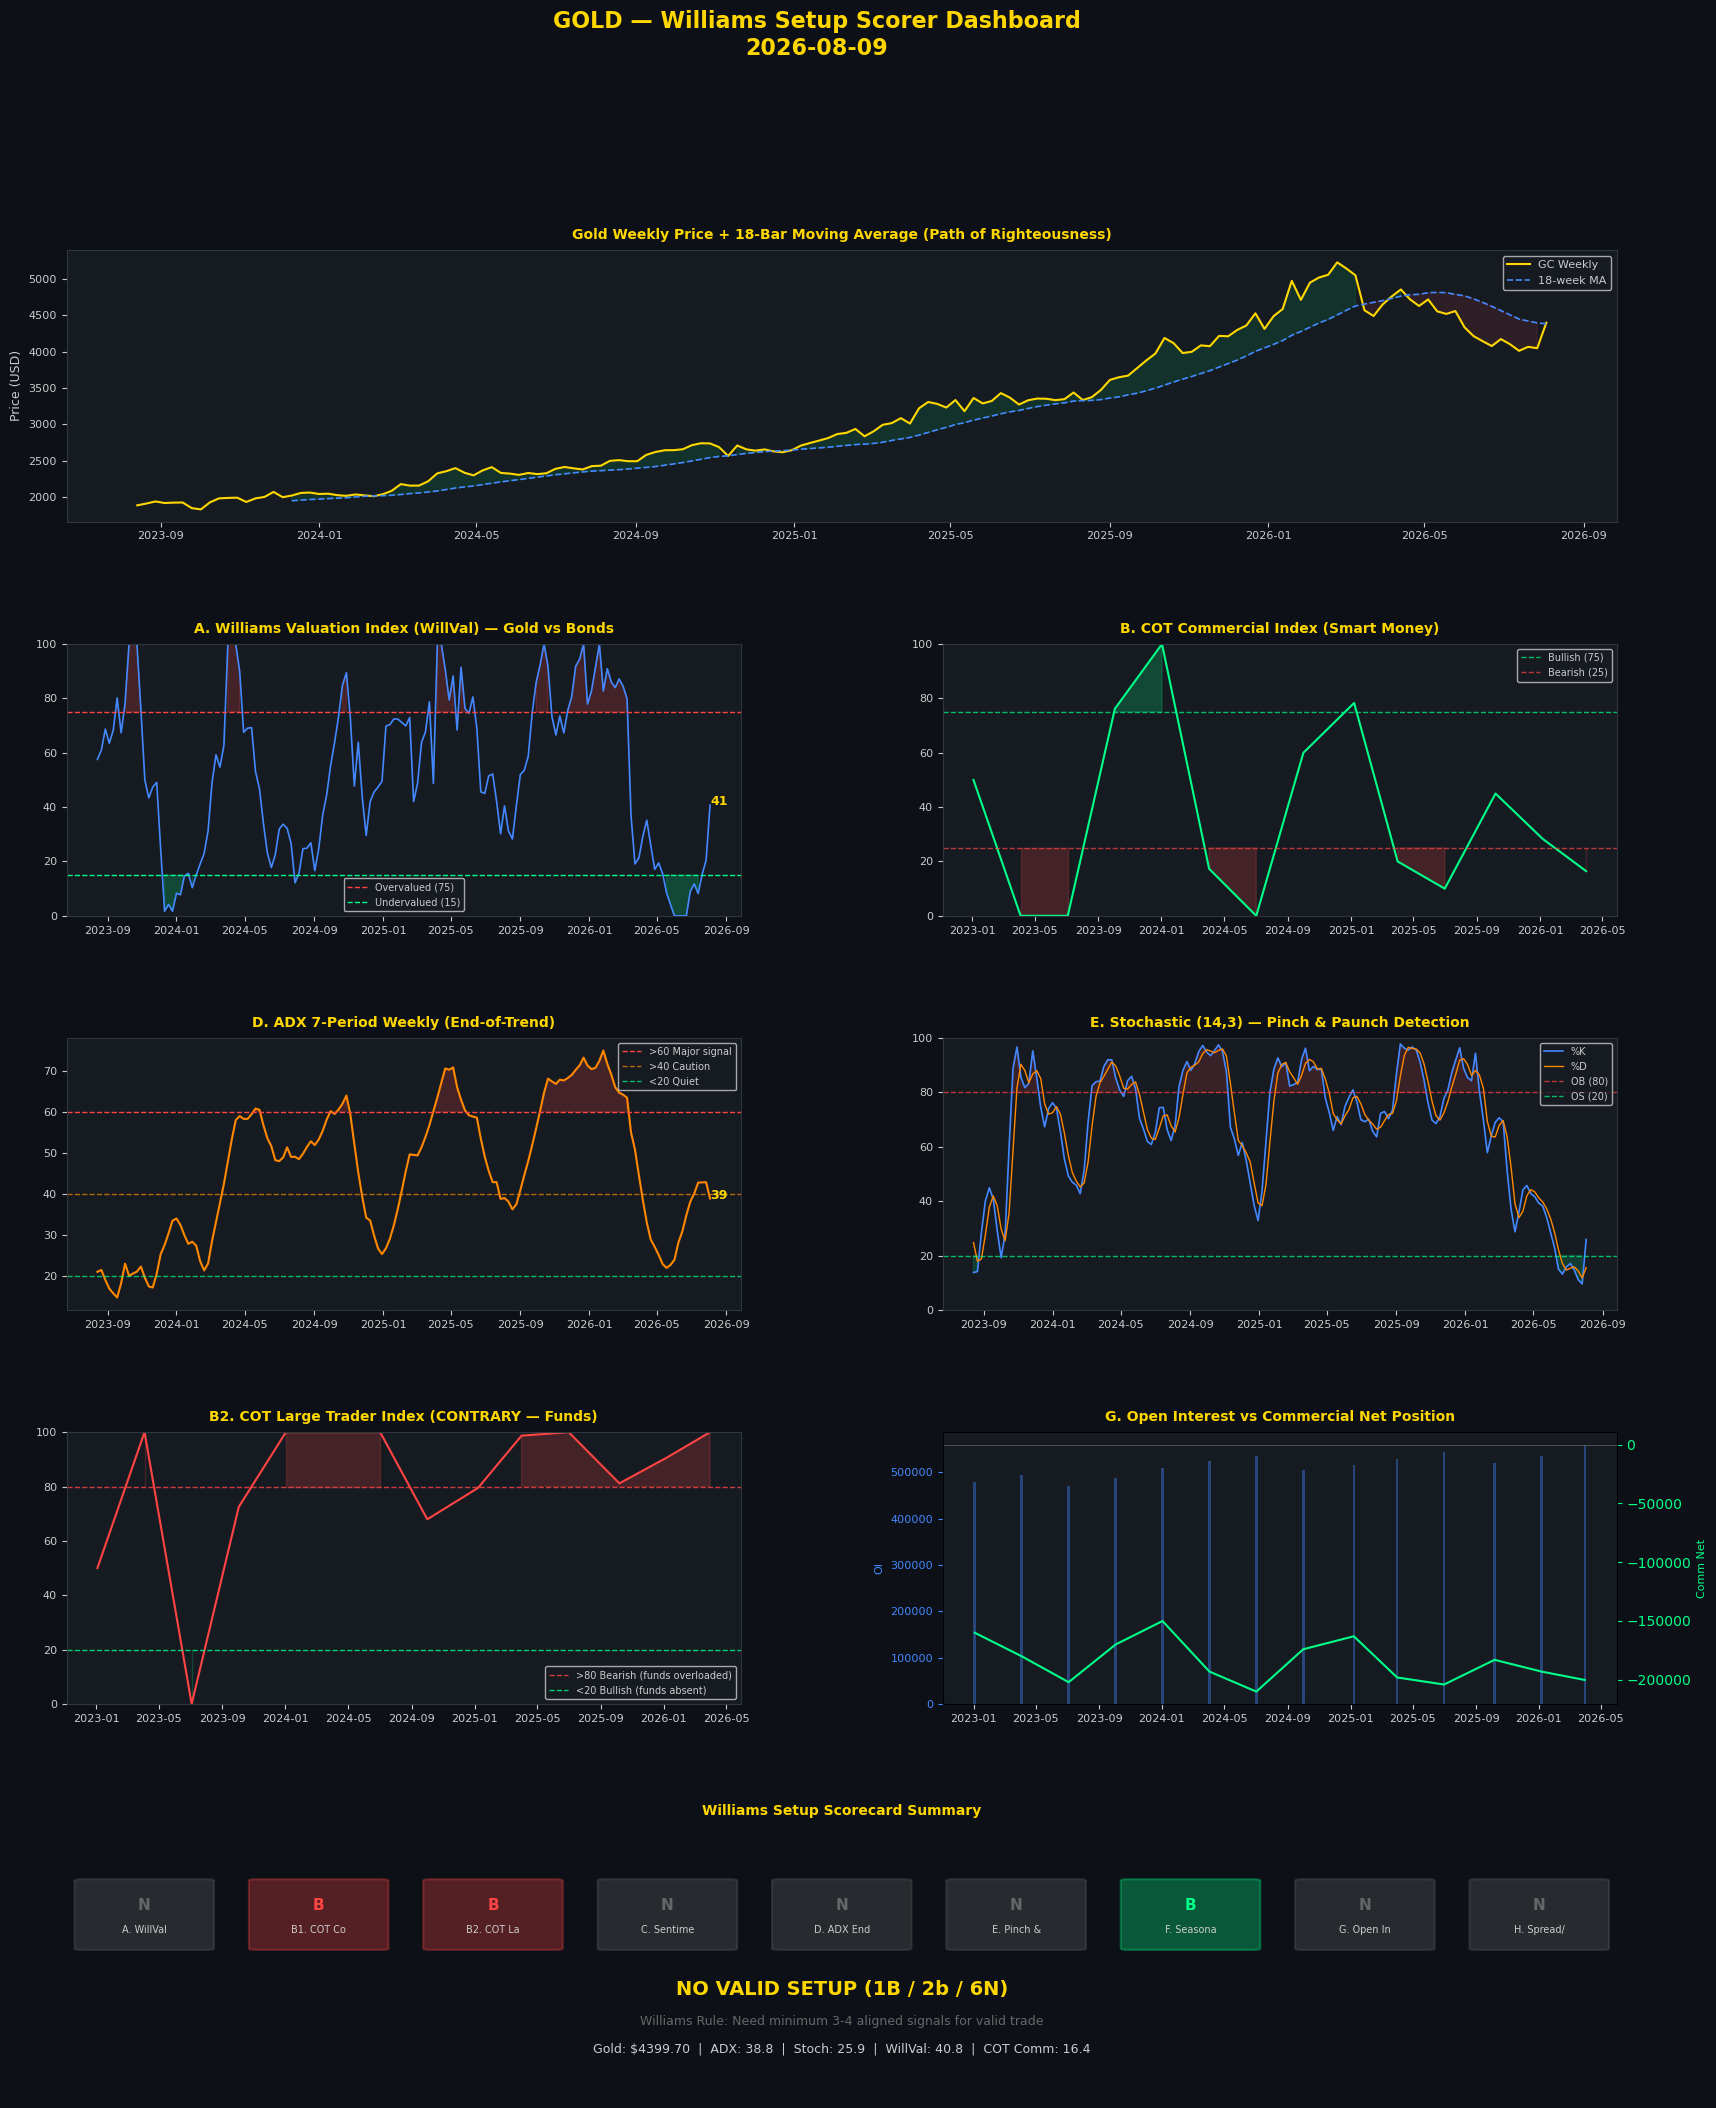

✅ Dashboard saved to: /Users/elena_nael/SUNDAY/Gold_Williams_Dashboard.png


In [6]:
# ============================================================
# CELL 6: VISUALISATION DASHBOARD
# ============================================================

fig = plt.figure(figsize=(20, 24), facecolor='#0d1117')
fig.suptitle(
    f'GOLD — Williams Setup Scorer Dashboard\n{datetime.now().strftime("%Y-%m-%d")}',
    color='#FFD700', fontsize=16, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.45, wspace=0.3)

PLOT_WEEKS = 156  # 3 years
gold_plot  = gold.iloc[-PLOT_WEEKS:]
cot_plot   = cot_df.iloc[-min(len(cot_df), 52):]  # 1 year of COT

DARK_BG   = '#0d1117'
GOLD_COL  = '#FFD700'
GREEN_COL = '#00ff88'
RED_COL   = '#ff4444'
BLUE_COL  = '#4488ff'
GRAY_COL  = '#666666'
TEXT_COL  = '#cccccc'

def style_ax(ax, title):
    ax.set_facecolor('#161b22')
    ax.tick_params(colors=TEXT_COL, labelsize=8)
    ax.set_title(title, color=GOLD_COL, fontsize=10, fontweight='bold', pad=8)
    for spine in ax.spines.values():
        spine.set_color('#30363d')

# ── 1. Gold Price + 18-week MA ────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
style_ax(ax1, 'Gold Weekly Price + 18-Bar Moving Average (Path of Righteousness)')
ma18 = gold_plot['Close'].rolling(18).mean()
ax1.plot(gold_plot.index, gold_plot['Close'], color=GOLD_COL, linewidth=1.5, label='GC Weekly')
ax1.plot(gold_plot.index, ma18, color=BLUE_COL, linewidth=1.2, linestyle='--', label='18-week MA')
ax1.fill_between(gold_plot.index, gold_plot['Close'], ma18,
                 where=gold_plot['Close'] >= ma18, alpha=0.1, color=GREEN_COL)
ax1.fill_between(gold_plot.index, gold_plot['Close'], ma18,
                 where=gold_plot['Close'] < ma18, alpha=0.1, color=RED_COL)
ax1.set_ylabel('Price (USD)', color=TEXT_COL, fontsize=9)
ax1.legend(facecolor='#161b22', labelcolor=TEXT_COL, fontsize=8)
ax1.yaxis.label.set_color(TEXT_COL)

# ── 2. WillVal ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
style_ax(ax2, 'A. Williams Valuation Index (WillVal) — Gold vs Bonds')
willval_plot = combined['willval'].iloc[-PLOT_WEEKS:]
ax2.plot(willval_plot.index, willval_plot, color=BLUE_COL, linewidth=1.2)
ax2.axhline(75, color=RED_COL,   linestyle='--', linewidth=1, label='Overvalued (75)')
ax2.axhline(15, color=GREEN_COL, linestyle='--', linewidth=1, label='Undervalued (15)')
ax2.fill_between(willval_plot.index, willval_plot, 75,
                 where=willval_plot >= 75, alpha=0.2, color=RED_COL)
ax2.fill_between(willval_plot.index, willval_plot, 15,
                 where=willval_plot <= 15, alpha=0.2, color=GREEN_COL)
ax2.set_ylim(0, 100)
ax2.legend(facecolor='#161b22', labelcolor=TEXT_COL, fontsize=7)
# Mark current value
ax2.annotate(f'{willval_current:.0f}', xy=(willval_plot.index[-1], willval_current),
             color=GOLD_COL, fontweight='bold', fontsize=9)

# ── 3. COT Commercial Index ───────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
style_ax(ax3, 'B. COT Commercial Index (Smart Money)')
ax3.plot(cot_plot.index, cot_plot['cot_comm_index'], color=GREEN_COL, linewidth=1.5)
ax3.axhline(75, color=GREEN_COL, linestyle='--', linewidth=1, alpha=0.7, label='Bullish (75)')
ax3.axhline(25, color=RED_COL,   linestyle='--', linewidth=1, alpha=0.7, label='Bearish (25)')
ax3.fill_between(cot_plot.index, cot_plot['cot_comm_index'], 75,
                 where=cot_plot['cot_comm_index'] >= 75, alpha=0.2, color=GREEN_COL)
ax3.fill_between(cot_plot.index, cot_plot['cot_comm_index'], 25,
                 where=cot_plot['cot_comm_index'] <= 25, alpha=0.2, color=RED_COL)
ax3.set_ylim(0, 100)
ax3.legend(facecolor='#161b22', labelcolor=TEXT_COL, fontsize=7)

# ── 4. ADX (7-period weekly) ──────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
style_ax(ax4, 'D. ADX 7-Period Weekly (End-of-Trend)')
adx_plot = gold_plot['adx_7']
ax4.plot(gold_plot.index, adx_plot, color='#ff8800', linewidth=1.5)
ax4.axhline(60, color=RED_COL,   linestyle='--', linewidth=1, label='>60 Major signal')
ax4.axhline(40, color='#ff8800', linestyle='--', linewidth=1, alpha=0.7, label='>40 Caution')
ax4.axhline(20, color=GREEN_COL, linestyle='--', linewidth=1, alpha=0.7, label='<20 Quiet')
ax4.fill_between(gold_plot.index, adx_plot, 60,
                 where=adx_plot >= 60, alpha=0.2, color=RED_COL)
ax4.legend(facecolor='#161b22', labelcolor=TEXT_COL, fontsize=7)
ax4.annotate(f'{adx_current:.0f}', xy=(gold_plot.index[-1], adx_current),
             color=GOLD_COL, fontweight='bold', fontsize=9)

# ── 5. Stochastics (Pinch & Paunch) ──────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
style_ax(ax5, 'E. Stochastic (14,3) — Pinch & Paunch Detection')
stoch_plot_k = gold_plot['stoch_k']
stoch_plot_d = gold_plot['stoch_d']
ax5.plot(gold_plot.index, stoch_plot_k, color=BLUE_COL,  linewidth=1.2, label='%K')
ax5.plot(gold_plot.index, stoch_plot_d, color='#ff8800', linewidth=1.0, label='%D')
ax5.axhline(80, color=RED_COL,   linestyle='--', linewidth=1, alpha=0.7, label='OB (80)')
ax5.axhline(20, color=GREEN_COL, linestyle='--', linewidth=1, alpha=0.7, label='OS (20)')
ax5.fill_between(gold_plot.index, stoch_plot_k, 80,
                 where=stoch_plot_k >= 80, alpha=0.15, color=RED_COL)
ax5.fill_between(gold_plot.index, stoch_plot_k, 20,
                 where=stoch_plot_k <= 20, alpha=0.15, color=GREEN_COL)
ax5.set_ylim(0, 100)
ax5.legend(facecolor='#161b22', labelcolor=TEXT_COL, fontsize=7)

# ── 6. COT Large Trader Index (Contrary) ─────────────────────
ax6 = fig.add_subplot(gs[3, 0])
style_ax(ax6, 'B2. COT Large Trader Index (CONTRARY — Funds)')
ax6.plot(cot_plot.index, cot_plot['cot_lt_index'], color=RED_COL, linewidth=1.5)
ax6.axhline(80, color=RED_COL,   linestyle='--', linewidth=1, alpha=0.8, label='>80 Bearish (funds overloaded)')
ax6.axhline(20, color=GREEN_COL, linestyle='--', linewidth=1, alpha=0.8, label='<20 Bullish (funds absent)')
ax6.fill_between(cot_plot.index, cot_plot['cot_lt_index'], 80,
                 where=cot_plot['cot_lt_index'] >= 80, alpha=0.2, color=RED_COL)
ax6.fill_between(cot_plot.index, cot_plot['cot_lt_index'], 20,
                 where=cot_plot['cot_lt_index'] <= 20, alpha=0.2, color=GREEN_COL)
ax6.set_ylim(0, 100)
ax6.legend(facecolor='#161b22', labelcolor=TEXT_COL, fontsize=7)

# ── 7. Open Interest ──────────────────────────────────────────
ax7 = fig.add_subplot(gs[3, 1])
style_ax(ax7, 'G. Open Interest vs Commercial Net Position')
ax7_twin = ax7.twinx()
ax7.bar(cot_plot.index, cot_plot['open_interest'],
        color=BLUE_COL, alpha=0.4, width=5, label='Open Interest')
ax7_twin.plot(cot_plot.index, cot_plot['comm_net'],
              color=GREEN_COL, linewidth=1.5, label='Comm Net')
ax7_twin.axhline(0, color=GRAY_COL, linewidth=0.5)
ax7.set_ylabel('OI', color=BLUE_COL, fontsize=8)
ax7_twin.set_ylabel('Comm Net', color=GREEN_COL, fontsize=8)
ax7.tick_params(axis='y', colors=BLUE_COL)
ax7_twin.tick_params(axis='y', colors=GREEN_COL)
ax7_twin.set_facecolor('#161b22')

# ── 8. Scorecard Summary ──────────────────────────────────────
ax8 = fig.add_subplot(gs[4, :])
ax8.set_facecolor('#161b22')
ax8.set_xlim(0, 10)
ax8.set_ylim(0, 10)
ax8.axis('off')
style_ax(ax8, 'Williams Setup Scorecard Summary')

score_labels = list(label_map.keys())
x_positions  = np.linspace(0.5, 9.5, len(score_labels))
color_map    = {'BULLISH': GREEN_COL, 'BEARISH': RED_COL, 'NEUTRAL': GRAY_COL}

for i, key in enumerate(score_labels):
    score = scores[key]
    col   = color_map[score]
    short_label = label_map[key].replace('   ', '').strip()[:10]

    rect = FancyBboxPatch((x_positions[i]-0.4, 5.5), 0.8, 2.5,
                           boxstyle='round,pad=0.05',
                           facecolor=col, alpha=0.3, edgecolor=col, linewidth=1.5)
    ax8.add_patch(rect)
    ax8.text(x_positions[i], 7.1, score[0], ha='center', va='center',
             color=col, fontweight='bold', fontsize=11)
    ax8.text(x_positions[i], 6.2, short_label, ha='center', va='center',
             color=TEXT_COL, fontsize=7, wrap=True)

# Score totals
verdict_color = GREEN_COL if bullish_count >= 4 else (RED_COL if bearish_count >= 4 else GOLD_COL)
verdict_text  = (f'BULLISH SETUP ({bullish_count}/9)' if bullish_count >= 4 else
                 f'BEARISH SETUP ({bearish_count}/9)' if bearish_count >= 4 else
                 f'NO VALID SETUP ({bullish_count}B / {bearish_count}b / {neutral_count}N)')

ax8.text(5, 4.0, verdict_text, ha='center', va='center',
         color=verdict_color, fontweight='bold', fontsize=14)
ax8.text(5, 2.8, f'Williams Rule: Need minimum 3-4 aligned signals for valid trade',
         ha='center', va='center', color=GRAY_COL, fontsize=9)
ax8.text(5, 1.8, f'Gold: ${gold["Close"].iloc[-1]:.2f}  |  ADX: {adx_current:.1f}  |  Stoch: {stoch_current:.1f}  |  WillVal: {willval_current:.1f}  |  COT Comm: {comm_idx:.1f}',
         ha='center', va='center', color=TEXT_COL, fontsize=9)

import os
save_path = os.path.join(os.getcwd(), 'Gold_Williams_Dashboard.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Dashboard saved to: {save_path}')

## 📋 Weekly Update Protocol

### Every Friday after market close:

1. **Go to:** https://www.cftc.gov/dea/options/deacmxlof.htm
2. **Find:** GOLD - COMMODITY EXCHANGE INC. (Code-088691)
3. **Read these numbers:**
   - Commercial Long (column: Commercial Long)
   - Commercial Short (column: Commercial Short)
   - Non-Commercial Long (Large Traders)
   - Non-Commercial Short (Large Traders)
   - Open Interest (first column)
4. **Add new row to COT_DATA in Cell 3:**
   ```python
   '2026-04-07': (comm_long, comm_short, nc_long, nc_short, open_interest),
   ```
5. **Update FAR_TICKER in Cell 4** if the contract has rolled
6. **Run All Cells** → fresh scorecard

---

### Williams COT Interpretation Quick Reference:

| Commercial Index | Signal |
|-----------------|--------|
| >75% | **BULLISH** — Commercials heavily long |
| <25% | **BEARISH** — Commercials heavily short |
| 52-week high | **BULLISH** regardless of absolute level |
| Crouch (rolling from extreme) | **Move has BEGUN** |

| Large Trader Index | Signal |
|-------------------|--------|
| >80% | **BEARISH** (contrary — funds piled in at tops) |
| <20% | **BULLISH** (contrary — funds absent at bottoms) |

| ADX (7-week) | Signal |
|-------------|--------|
| >60 in rally | **SELL** — major top near |
| >60 in decline | **BUY** — major bottom near |
| <20 + Commercials buying | **IMMEDIATE BUY** |
| New price high, ADX not | **BEARISH DIVERGENCE** |